# Topology

CodeToCAD automates CAD modeling.

To do this well, we should understand how popular modeling software go about creating 3D models.

#### We will consider these popular modeling techniques:

1. [NURBS](https://en.wikipedia.org/wiki/Non-uniform_rational_B-spline) based [Boundary Represenstation](https://en.wikipedia.org/wiki/Boundary_representation) (BREP)
2. [Polygon Mesh](https://en.wikipedia.org/wiki/Polygon_mesh) (We'll call this 'Mesh')
3. [Signed Distance Field](https://en.wikipedia.org/wiki/Signed_distance_function) (SDF)

#### Some topology jargon:
- **Vertex**: a 3D point that may be connected to zero or many other vertices. [1]
- **Edge**: a line or spline bounded by two vertices. [1]
- **Wire**: a collection of edges. [1]
- **Surface**: a closed wire.
    - **Face** is a subset of surface. [1]
- **Volume**: a closed collection of surfaces. [1]


##### Friendly references on topology:
[1] [https://dev.opencascade.org/sites/default/files/pdf/Topology.pdf](https://dev.opencascade.org/sites/default/files/pdf/Topology.pdf)

[2] [https://dev.opencascade.org/doc/overview/html/occt_user_guides__modeling_data.html](https://dev.opencascade.org/doc/overview/html/occt_user_guides__modeling_data.html)


#### These software will represent those techniques:
1. **BREP**: [Build123d](https://github.com/gumyr/build123d) and its underlying [OpenCASCAD](https://github.com/Open-Cascade-SAS/OCCT), [Onshape](https://www.onshape.com), [Fusion360](https://www.autodesk.com/products/fusion-360)
2. **Mesh**: [Blender](https://www.blender.org/), [OpenSCAD](https://openscad.org/) and its underlying [OpenCSG](https://opencsg.org/).
3. **SDF**: [Libfive](https://libfive.com/)

#### What we learned from CodeToCAD Legacy

CodeToCAD Legacy, which we'll refer to as Legacy from now on, skipped over defining sketching capabilities and implemented higher level 3D shapes.

This was fine for very simple shapes, however, it became very cumbersome to do anything useful past the first few [examples](https://github.com/CodeToCAD/CodeToCAD/tree/codetocad_legacy/examples).

#### Examples from other code-CAD libraries

Several code-CAD libraries go about doing sketching using code-CAD
- **replicad**: https://replicad.xyz/docs/examples/simple-vase :

    ```javascript
        let vase = sketchVaseProfile
            .lineTo([0, height])
            .close()
            .sketchOnPlane("XZ")
            .revolve();

        if (wallThickness) {
            vase = vase.shell(wallThickness, (f) => f.containsPoint([0, 0, height]));
        }

        if (topFillet) {
            vase = vase.fillet(wallThickness / 3, (e) => e.inPlane("XY", height));
        }
    ```
    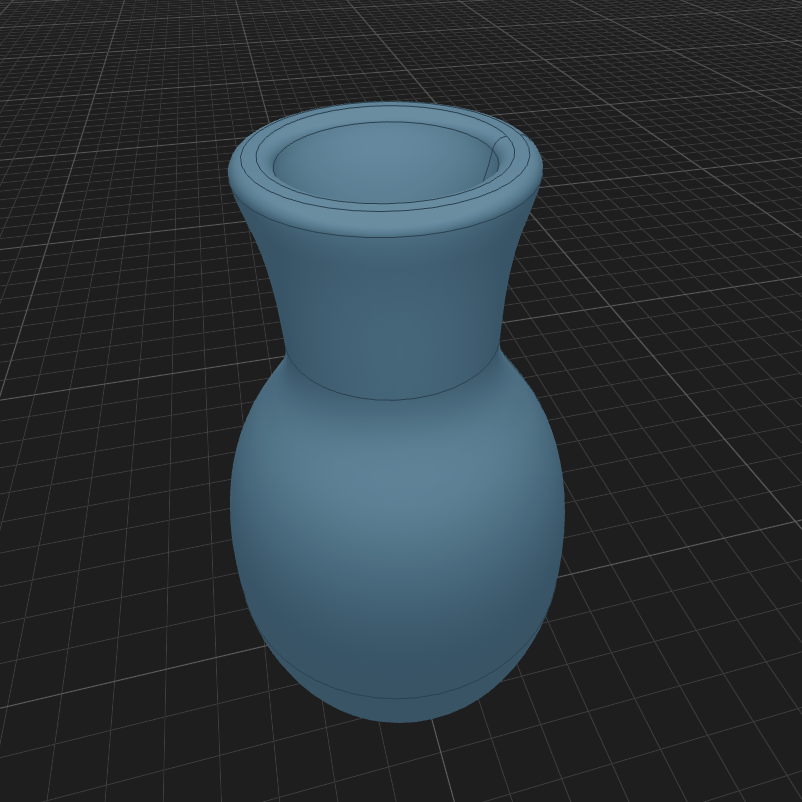

    > Personal commentary: Replicad's syntax is simple and straightforward, however, understanding which methods are applicable in which contextual situations is a little tricky and requisites a working knowledge of the API.

- **build123d**: https://github.com/gumyr/build123d/blob/dev/examples/vase.py :

    ```python
        with BuildPart() as vase:
            with BuildSketch() as profile:
                with BuildLine() as outline:
                    l1 = Line((0, 0), (12, 0))
                    l2 = RadiusArc(l1 @ 1, (15, 20), 50)
                    l3 = Spline(l2 @ 1, (22, 40), (20, 50), tangents=(l2 % 1, (-0.75, 1)))
                    l4 = RadiusArc(l3 @ 1, l3 @ 1 + Vector(0, 5), 5)
                    l5 = Spline(
                        l4 @ 1,
                        l4 @ 1 + Vector(2.5, 2.5),
                        l4 @ 1 + Vector(0, 5),
                        tangents=(l4 % 1, (-1, 0)),
                    )
                    Polyline(
                        l5 @ 1,
                        l5 @ 1 + Vector(0, 1),
                        (0, (l5 @ 1).Y + 1),
                        l1 @ 0,
                    )
                make_face()
            revolve(axis=Axis.Y)
            offset(openings=vase.faces().filter_by(Axis.Y)[-1], amount=-1)
            top_edges = (
                vase.edges().filter_by_position(Axis.Y, 60, 62).filter_by(GeomType.CIRCLE)
            )
            fillet(top_edges, radius=0.25)
    ```

    > Personal commentary: Build123D is very powerful. The use of context-entry is uncommon and helps the user understand the context. The ability to create edges and wires, then join them using the @ operator is simple and easy to follow. The operations are a little low-level though, making understanding the shapes created a little difficult. This is not a con - the nature of CodeCAD makes it difficult to visualize geometry. B123D has a very robust API.

Several more code-CAD tools are listed in this awesome list: https://github.com/Irev-Dev/curated-code-cad

## CodeToCAD isn't a code-CAD library, it's an automation. We want to do a little more than just define shapes. We want to connect processes.

## Problem Definition

This raises the question: *Shoud CodeToCAD deal with defining shapes at all?*

[Legacy](https://github.com/CodeToCAD/CodeToCAD/tree/codetocad_legacy/) wanted to provide an abstraction for all modeling processes. "One language for all your CAD needs".

## However, what problem is this really solving? People were interested in the idea of using a simpler python API to interact with Blender and Onshape, but this is not really manufacturing automation.

The **problem** is that hardware iteration is hard because the requirements space is unbounded; designing a wearable is vastly different from designing a vehicle or AMR. 

The **problem** is that an engineer could spend a week designing a part, send it to manufacturing, get back a few weeks later to find that pieces don't fit or requirements have changed.

The **problem** is that modern systems are multi-disciplinary. A mechanical engineer works closely with an electrical, software and design engineer to produce a single working prototype. Metcalfe's Law hits hard.

The **problem** is that the lack of clear requirements, knowledge and experience in a team leads to huge underestimation of effort.

The **problem** is that very complex CAD software has been developed to cater to engineers' needs to do the job. A seasoned mechanical engineer will tell you that modeling doesn't take as much time as requirements gathering and research. However, maintaining a CAD model is like maintaining a piece of software: as complexity grows, making changes incurs risk. 

A **hypothesis** is that complex CAD software is very impressive, but the interface is a bottleneck for efficiency in a modern digital manufacturing world.

### Perhaps the manufacturing automation I envision looks more like this:

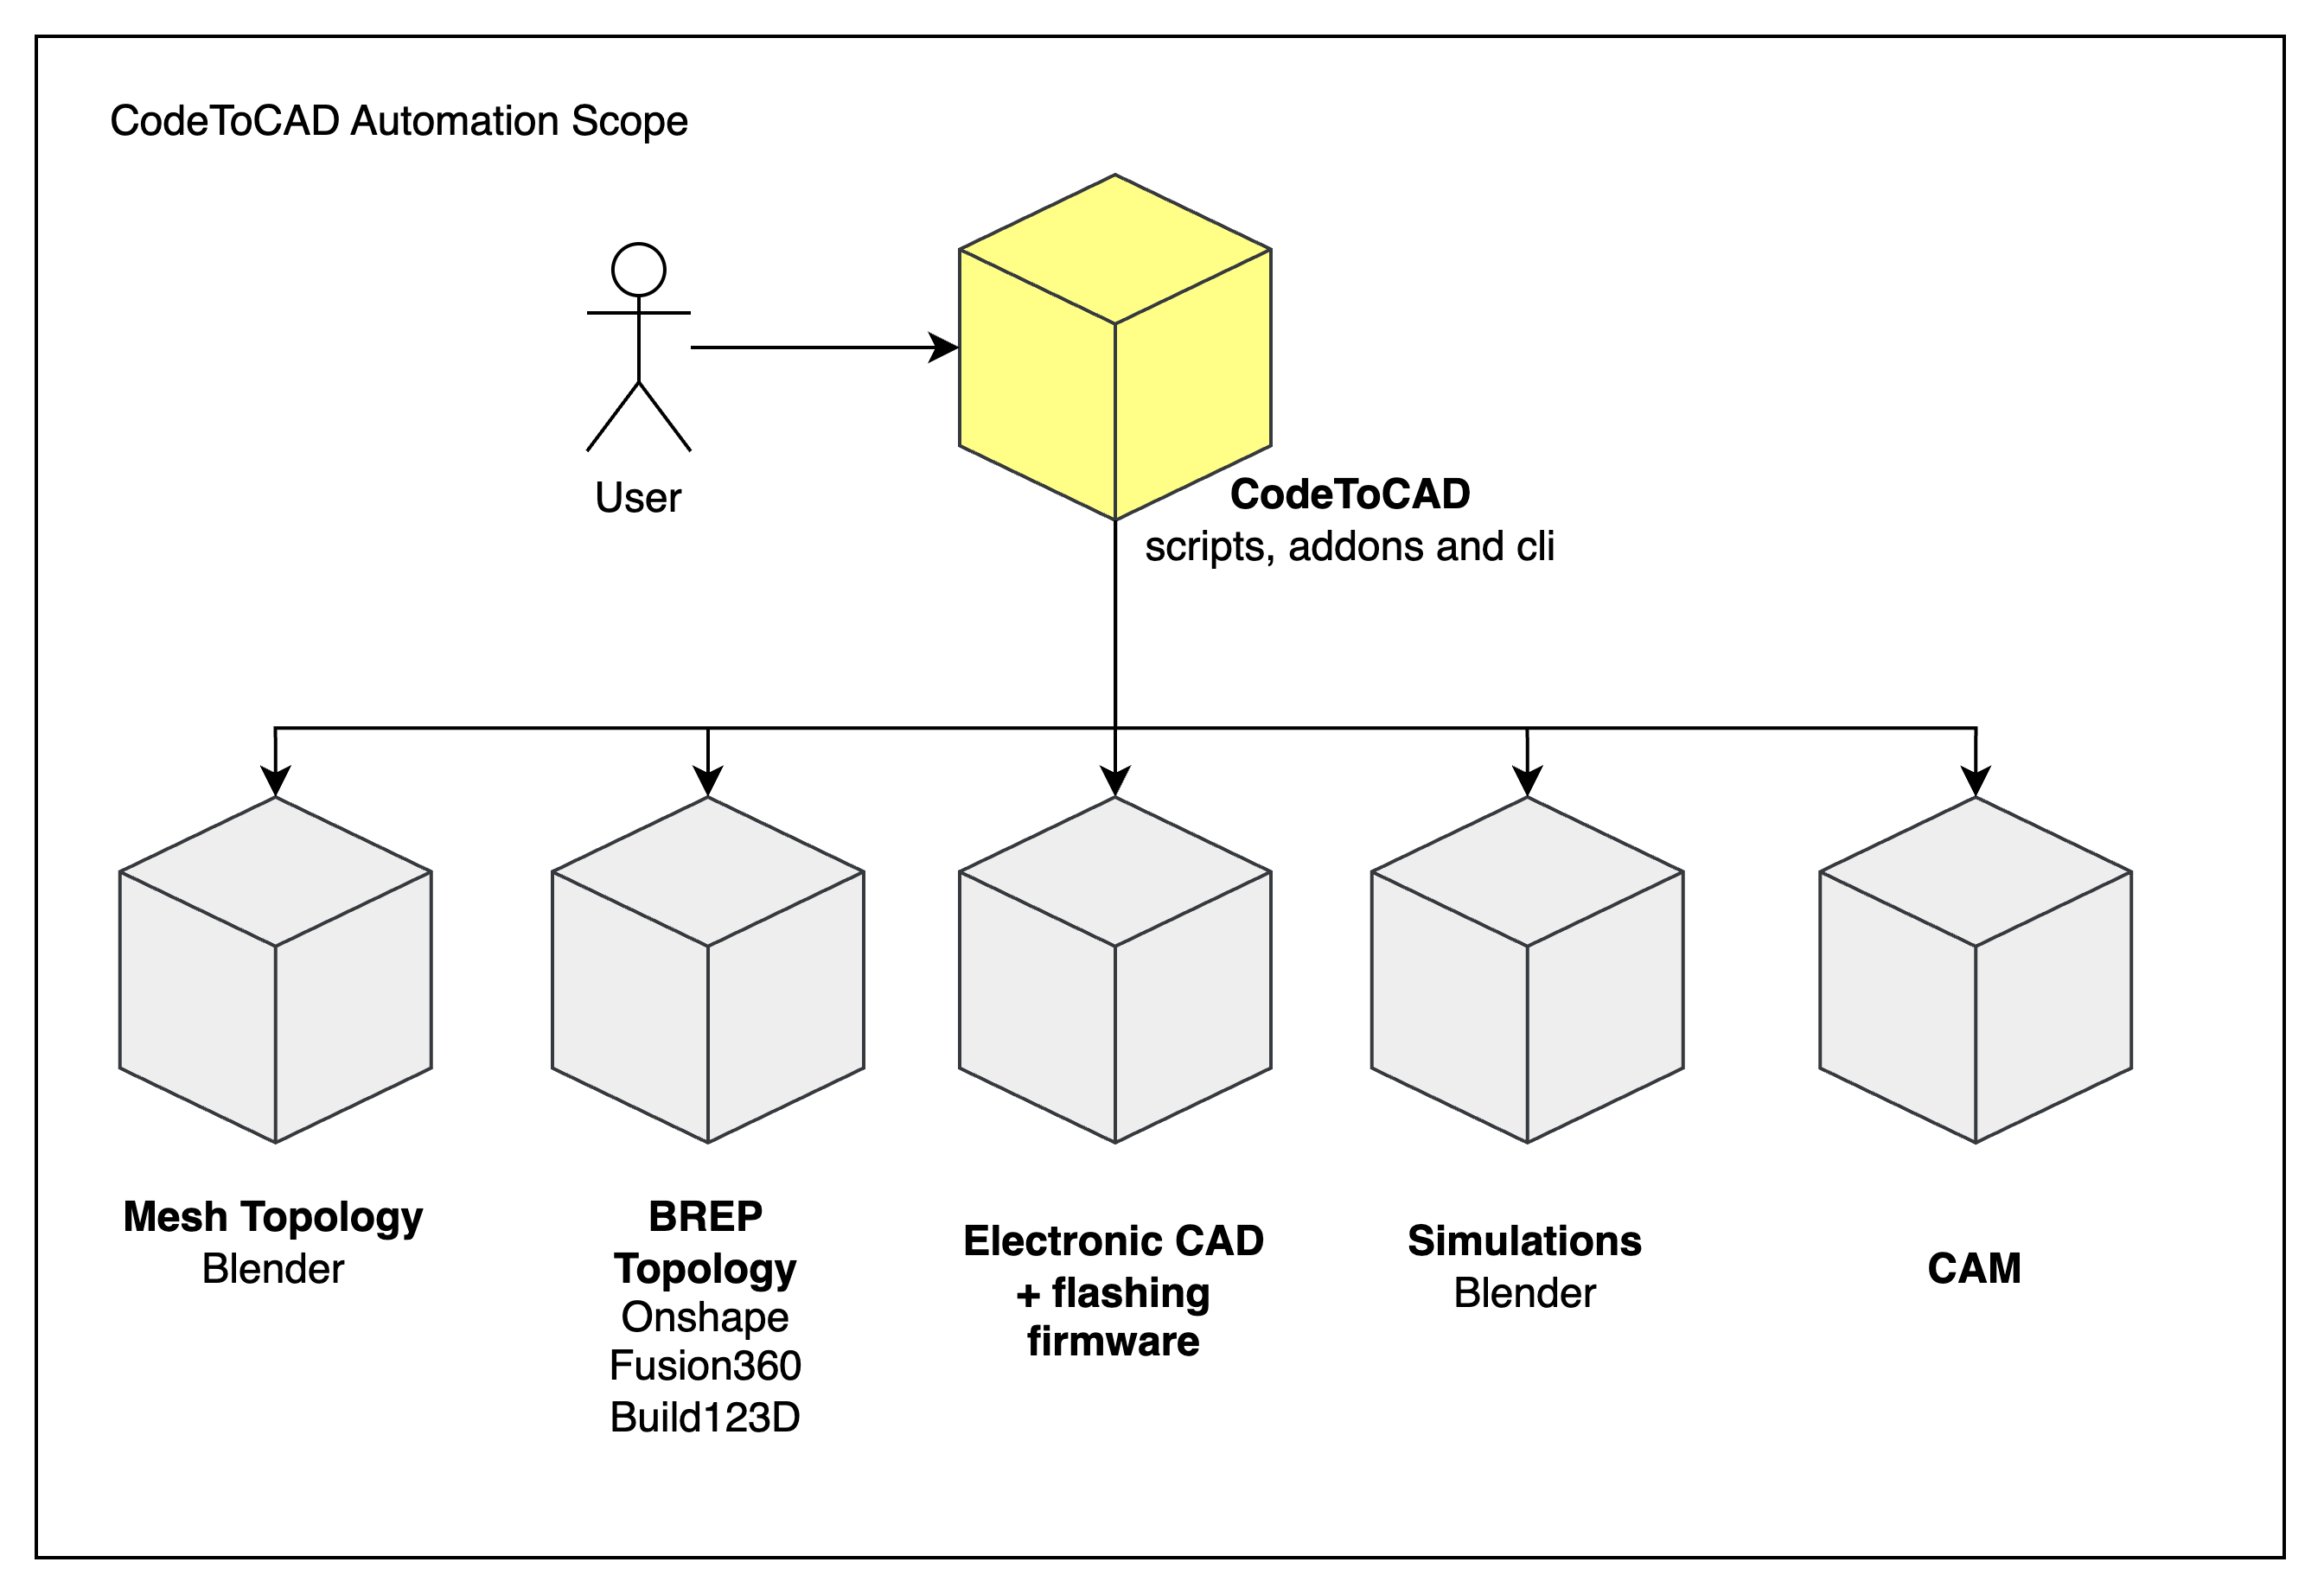

In the most succinct way, the problem is that R&D design iteration is fragmented. Every component is handled by a different team, and communication is slow and difficult.

Design components:
1. Requirements gathering: material, dimensionality, torque, sensing, power, wired/wireless communication, safety, certificate/iso/standards, time/cost constraints. 
2. Sketches/Scrap prototypes based on requirements.
3. Create and assemble hardware.
4. Create and assemble electronics.
5. Fit software to hardware and electronic assemblies.
6. If any of the hardware changes, electronics is likely to change. If any of hardware or electronics change, software is likely to change. If any of the initial requirements change, all of them are changing.

Since R&D is tied to market, the following should be considered as well:

7. Manufacturing and assembly logistics.
8. Internal inventory, operational and shipping support.
9. Customer Support for hardware, electronics, software.
10. End-of-life, refurbrishment and recycling support.

To solve the problem of fragmented design components, CodeToCAD needs to provide a framework for interweaving these problems into an automated flow.

Perhaps something like:

1. Capture requirements in one place.
2. Aid in creating sketches and scrap prototypes. Log those for future design considerations.
3. Create and assemble hardware
    - Define the shapes that make up my design, either from existing models or ones that I custom build.
    - Create an assembly with contraints between the shapes. 
    - This assumes pcb's, sensors, actuators, power delivery sources are incorporated into the shapes making up the assemblies.
4. Create and assemble the electronics
    - Define the components, schematics, footprints
    - Create an assembly
5. Using the definition of joints, sensors, electronics, communication protocols and business processed, build out controls, communication and pipelines.
6. Changing anything in the designs should automatically reflect in dependencies.
7. Capture plans for manufacturing and assembly.
8. Provide a way to track inventory and shipping.
9. Provide an easy way to track and provide customer support.
10. Capture protocol for EoL and refurbrishment.

Putting this all together, it should look something like this:

```
- Conveyor belt with RFID reader and prismatic pushers
-- Requirements
--- An industry 4.0/5.0 conveyor belt with an RFID reader and several prismatic pushers that are time-delay activated after a box of dimension 30cm cubed has been scanned on the conveyor.
--- The belt should be at least 2m long, and the pushers 1m apart.
-- Prototype ideas
--- Belt mounted between two drums, one of the drums is actuated by a 2HP DC motor. RFID reader is placed under the belt. The pushers are mounted along the belt.
-- Hardware
--- 
```

All these items have GUI-based solutions, again, fragmented into many software. Some companies, like PTC or AutoDesk are trying to bundle these together, but in a very corporate, vendor-locked manner.

CodeToCAD wants to offer this in an OSS manner.
 

---------------